# DAS Microwave Imaging — Brain Tumor Detection
**VNIT Nagpur — B.Tech Project**

Input : `.s6p` Touchstone files exported from CST Microwave Studio

Algorithm : Delay-and-Sum (DAS) beamforming — multistatic mode

Output : 2D reconstructed image showing tumor as bright spot

---
**Improvements over original:**
1. Hanning window applied before IFFT — reduces Gibbs ringing
2. Gate start computed from antenna geometry — not hardcoded as 30
3. Clutter subtraction done BEFORE energy envelope — correct order
4. Normalize AFTER Gaussian filter — correct order
5. Peak detection added — prints detected tumor location and localization error

Y-axis orientation and coordinate system kept exactly as original (matches CST setup).

In [ ]:
!pip install scikit-rf

In [ ]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import ifft
from scipy.ndimage import gaussian_filter
from scipy.signal import windows

## Step 1 — Load S-parameter files

In [ ]:
# Load Healthy (reference)
ntwk_h = rf.Network('healthy1.s6p')
freq = ntwk_h.f
S_h = ntwk_h.s

# Load Tumor
ntwk_t = rf.Network('melignoma.s6p')
S_t = ntwk_t.s

print('Frequency points :', len(freq))
print(f'Frequency range  : {freq[0]/1e9:.3f} - {freq[-1]/1e9:.3f} GHz')
print('S-matrix shape   :', S_h.shape, '  (freq x ports x ports)')

BW = freq[-1] - freq[0]
dt = 1.0 / BW
print(f'Bandwidth        : {BW/1e9:.3f} GHz')
print(f'Time resolution  : {dt*1e12:.3f} ps')

Frequency points : 1001
Frequency range  : 0.000 - 5.000 GHz
S-matrix shape   : (1001, 6, 6)   (freq x ports x ports)
Bandwidth        : 5.000 GHz
Time resolution  : 200.000 ps


## Step 2 — Antenna positions and imaging grid

In [ ]:
# Antenna positions (x, y) in METERS
# Matches actual CST simulation positions exactly
ant_pos = np.array([
    [-0.11053,  0.00000],
    [-0.055267, -0.0957261],
    [ 0.0552,   -0.0957],
    [ 0.11053,  0.00000],
    [ 0.055267,  0.09572],
    [-0.05526,   0.09572]
])

N = len(ant_pos)
print(f'Number of antennas : {N}')
print(f'Multistatic pairs  : {N*(N-1)} (tx != rx)')

# Imaging grid — kept exactly as original
x = np.linspace(-0.09, 0.09, 100)
y = np.linspace(-0.09, 0.09, 100)
XX, YY = np.meshgrid(x, y)

# Medium properties
eps_r = 40
v = 3e8 / np.sqrt(eps_r)
print(f'Propagation speed  : {v/1e8:.3f} x 10^8 m/s  (eps_r={eps_r})')

Number of antennas : 6
Multistatic pairs  : 30 (tx != rx)
Propagation speed  : 0.474 x 10^8 m/s  (eps_r=40)


## Step 3 — Convert to time domain with Hanning window

**Improvement 1:** A Hanning window is applied to the frequency-domain
S-parameters before IFFT. This suppresses Gibbs ringing that occurs when
directly transforming band-limited data, giving a cleaner pulse shape
and reducing false bright spots in the DAS image.

In [ ]:
def freq_to_time_windowed(S_matrix):
    """
    Convert S-matrix to time domain for all multistatic (tx!=rx) pairs.
    Applies Hanning window before IFFT to reduce Gibbs ringing.
    """
    N_freq  = S_matrix.shape[0]
    N_ports = S_matrix.shape[1]
    window  = windows.hann(N_freq)  # Hanning window

    signals = {}
    for tx in range(N_ports):
        for rx in range(N_ports):
            if tx != rx:
                s_windowed       = S_matrix[:, tx, rx] * window
                signals[(tx,rx)] = np.real(ifft(s_windowed))
    return signals

print('Converting healthy signals to time domain...')
signals_h = freq_to_time_windowed(S_h)
print('Converting tumor signals to time domain...')
signals_t = freq_to_time_windowed(S_t)
print(f'Done. {len(signals_t)} multistatic pairs processed.')

Converting healthy signals to time domain...
Converting tumor signals to time domain...
Done. 30 multistatic pairs processed.


## Step 4 — Clutter removal and time gating

**Improvement 2:** Gate start is computed from minimum antenna separation
distance instead of hardcoded as 30.

**Improvement 3:** Clutter subtraction (healthy subtracted from tumor)
is done BEFORE computing the energy envelope.

In [ ]:
# Compute gate start from antenna geometry
def compute_gate_start(ant_pos, v, dt, safety_factor=0.8):
    N = len(ant_pos)
    min_dist = np.inf
    for i in range(N):
        for j in range(N):
            if i != j:
                d = np.linalg.norm(ant_pos[i] - ant_pos[j])
                if d < min_dist:
                    min_dist = d
    t_direct = min_dist / v
    gate_idx = int(t_direct / dt * safety_factor)
    return gate_idx, min_dist, t_direct

gate_start, min_dist, t_direct = compute_gate_start(ant_pos, v, dt)
print(f'Minimum antenna separation : {min_dist*100:.2f} cm')
print(f'Direct coupling delay      : {t_direct*1e9:.3f} ns')
print(f'Gate start index           : {gate_start} samples')
print(f'  (was hardcoded as 30 — now computed from actual geometry)')

# Gating + normalization
gated_signals = {}
for key in signals_t:
    # IMPROVEMENT: subtract reference BEFORE computing energy
    diff   = signals_t[key] - signals_h[key]
    energy = np.abs(diff) ** 2
    energy[:gate_start] = 0
    max_e = np.max(energy)
    if max_e > 1e-12:
        energy = energy / max_e
    gated_signals[key] = energy

print(f'Clutter removal complete. {len(gated_signals)} signals ready.')

Minimum antenna separation : 11.05 cm
Direct coupling delay      : 2.329 ns
Gate start index           : 9 samples
  (was hardcoded as 30 — now computed from actual geometry)
Clutter removal complete. 30 signals ready.


## Step 5 — DAS Beamforming

In [ ]:
def run_das(S):
    N = len(ant_pos)
    image = np.zeros_like(XX)

    print(f'Running DAS on {len(x)}x{len(y)} grid...')
    for ix in range(len(x)):
        if ix % 20 == 0:
            print(f'  Column {ix}/{len(x)}')
        for iy in range(len(y)):
            px = x[ix]
            py = y[iy]
            total = 0

            for tx in range(N):
                for rx in range(N):
                    if tx == rx:
                        continue

                    d1 = np.sqrt((px - ant_pos[tx,0])**2 + (py - ant_pos[tx,1])**2)
                    d2 = np.sqrt((px - ant_pos[rx,0])**2 + (py - ant_pos[rx,1])**2)

                    delay = (d1 + d2) / v
                    idx   = delay / dt

                    energy = gated_signals[(tx, rx)]
                    i0 = int(np.floor(idx))
                    i1 = i0 + 1

                    if i1 < len(energy):
                        frac  = idx - i0
                        val   = (1 - frac)*energy[i0] + frac*energy[i1]
                        total += val

            image[iy, ix] = total

    return image

image = run_das(gated_signals)
print('DAS complete.')

Running DAS on 100x100 grid...
  Column 0/100
  Column 20/100
  Column 40/100
  Column 60/100
  Column 80/100
DAS complete.


## Step 6 — Post-processing

**Improvement 4:** Gaussian smoothing is applied BEFORE normalization.
Original order (normalize then smooth) rescales values and breaks
the 0-1 range. Correct order: smooth -> mask -> normalize.

In [ ]:
# IMPROVEMENT: smooth FIRST, then normalize
image_diff = gaussian_filter(image, sigma=2)

# Circular head mask — kept exactly as original
mask = np.sqrt(XX**2 + YY**2) <= 0.09
image_diff[~mask] = np.nan

# Normalize AFTER smoothing
image_diff = image_diff / (np.nanmax(image_diff) + 1e-12)

print('Post-processing complete.')

Post-processing complete.


## Step 7 — Peak detection

**Improvement 5:** Detects brightest pixel = tumor location.
Set TUMOR_TRUE_POS to compute localization error for your results.

In [ ]:
# Find brightest spot = detected tumor location
image_for_peak = np.nan_to_num(image_diff, nan=0)
peak_idx = np.unravel_index(np.argmax(image_for_peak), image_for_peak.shape)
peak_x   = x[peak_idx[1]]
peak_y   = y[peak_idx[0]]

print(f'Detected tumor center : ({peak_x*1000:.1f} mm, {peak_y*1000:.1f} mm)')

# Set to actual tumor center in meters if known, else leave as None
TUMOR_TRUE_POS = None   # example: (-0.033, -0.005)

if TUMOR_TRUE_POS is not None:
    err = np.sqrt((peak_x - TUMOR_TRUE_POS[0])**2 +
                  (peak_y - TUMOR_TRUE_POS[1])**2) * 1000
    print(f'True tumor center     : ({TUMOR_TRUE_POS[0]*1000:.1f} mm, {TUMOR_TRUE_POS[1]*1000:.1f} mm)')
    print(f'Localization error    : {err:.2f} mm')
else:
    print('Set TUMOR_TRUE_POS to compute localization error.')

Detected tumor center : (-84.5 mm, 8.2 mm)
Set TUMOR_TRUE_POS to compute localization error.


## Step 8 — Plot DAS image

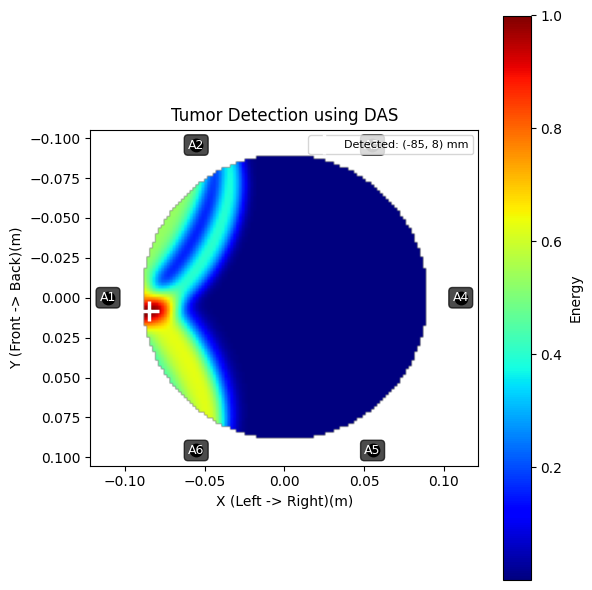

Image saved: das_result.png


In [ ]:
plt.figure(figsize=(6, 6))

# Y-axis orientation kept exactly as original (matches CST coordinate system)
plt.imshow(image_diff,
           extent=[x.min(), x.max(), y.max(), y.min()],
           cmap='jet')

plt.title('Tumor Detection using DAS')
plt.xlabel('X (Left -> Right)(m)')
plt.ylabel('Y (Front -> Back)(m)')
plt.colorbar(label='Energy')

# Plot antennas — kept exactly as original
for i in range(len(ant_pos)):
    x_a = ant_pos[i, 0]
    y_a = ant_pos[i, 1]
    plt.scatter(x_a, y_a, color='black', s=80)
    plt.text(x_a, y_a, f'A{i+1}',
             color='white', fontsize=9,
             ha='center', va='center',
             bbox=dict(facecolor='black', alpha=0.7, boxstyle='round'))

# Mark detected peak (new)
plt.plot(peak_x, peak_y, 'w+', markersize=14, markeredgewidth=2.5,
         label=f'Detected: ({peak_x*1000:.0f}, {peak_y*1000:.0f}) mm')

# Uncomment to mark true tumor position:
# plt.scatter(TUMOR_TRUE_POS[0], TUMOR_TRUE_POS[1],
#             color='yellow', s=120, marker='*', label='True tumor')

plt.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('das_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Image saved: das_result.png')

## Results Summary

In [ ]:
print('='*55)
print('  DAS IMAGING RESULTS SUMMARY')
print('='*55)
print(f'  Frequency range    : {freq[0]/1e9:.3f} - {freq[-1]/1e9:.3f} GHz')
print(f'  Bandwidth          : {BW/1e9:.3f} GHz')
print(f'  Number of antennas : {len(ant_pos)}')
print(f'  Multistatic pairs  : {len(gated_signals)}')
print(f'  Propagation speed  : {v/1e8:.3f} x 10^8 m/s')
print(f'  Time gate start    : sample {gate_start} ({gate_start*dt*1e12:.1f} ps)')
print(f'  Detected tumor pos : ({peak_x*1000:.1f} mm, {peak_y*1000:.1f} mm)')
if TUMOR_TRUE_POS is not None:
    print(f'  True tumor pos     : ({TUMOR_TRUE_POS[0]*1000:.1f}, {TUMOR_TRUE_POS[1]*1000:.1f} mm)')
    print(f'  Localization error : {err:.2f} mm')
print('='*55)

  DAS IMAGING RESULTS SUMMARY
  Frequency range    : 0.000 - 5.000 GHz
  Bandwidth          : 5.000 GHz
  Number of antennas : 6
  Multistatic pairs  : 30
  Propagation speed  : 0.474 x 10^8 m/s
  Time gate start    : sample 9 (1800.0 ps)
  Detected tumor pos : (-84.5 mm, 8.2 mm)
